# Лекция 2: Что такое нейросеть

В этом ноутбуке:
1. Из чего состоит нейросеть (нейрон, веса, слои)
2. Что такое `Dense` слой
3. Функции активации (`ReLU`, `sigmoid`, `softmax`)
4. Что такое `loss`, `Dropout`, оптимизаторы
5. Что делают `fit()` и `predict()`
6. Пример 1: бинарная классификация (две луны)
7. Пример 2: распознавание цифр

Цель: понять из каких простых кирпичиков собирается нейросеть.

In [22]:
# Установка библиотек (выполнить один раз)
!pip install -q numpy pandas matplotlib seaborn scikit-learn tensorflow
# !uv pip install numpy pandas matplotlib seaborn scikit-learn tensorflow && uv sync

zsh:1: command not found: pip


In [3]:
import random
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from IPython.display import display
from sklearn.datasets import load_digits, make_moons
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from tensorflow import keras
from tensorflow.keras import layers

np.random.seed(42)
random.seed(42)
keras.utils.set_random_seed(42)

plt.style.use("seaborn-v0_8")
pd.set_option("display.max_columns", 50)


## 1. Что такое нейросеть

Представьте таблицу с числами. Нейросеть — это программа, которая берет числа на входе, прогоняет их через несколько слоев вычислений и выдает ответ.

### Нейрон — самая маленькая деталь

Один нейрон делает всего два действия:
1. Умножает каждый вход на свой коэффициент (вес) и складывает: `z = w1*x1 + w2*x2 + b`
2. Пропускает результат через функцию активации

### Словарик
| Термин | Что это простыми словами |
|---|---|
| **Вход (feature)** | Число, которое приходит в модель |
| **Вес (weight)** | Коэффициент важности входа |
| **Смещение (bias)** | Дополнительный сдвиг |
| **Активация** | Нелинейное преобразование после суммы |
| **Слой (layer)** | Группа нейронов |
| **Loss** | Число, показывающее насколько модель ошиблась |
| **Оптимизатор** | Алгоритм, который подправляет веса |

### Что такое `Dense`

`Dense` — это **полносвязный слой**: каждый вход соединен с каждым нейроном.

Пример: 2 входа и 4 нейрона означает, что каждый из 4 нейронов получает оба входа.

### Сколько нейронов ставить

Жесткого правила нет — это подбирается экспериментально. Больше нейронов = больше гибкости, но и больше риск переобучения.

In [4]:
# Один нейрон вручную

x = np.array([2.0, -1.5])     # два входных признака
w = np.array([0.8, -0.4])     # два веса
b = 0.2                       # смещение

z = np.dot(x, w) + b
relu_output = max(0, z)
sigmoid_output = 1 / (1 + np.exp(-z))

result_df = pd.DataFrame({
    "компонент": ["x1", "x2", "w1", "w2", "bias", "z", "ReLU(z)", "sigmoid(z)"],
    "значение": [x[0], x[1], w[0], w[1], b, z, relu_output, sigmoid_output]
})

print("Формула нейрона: z = w1*x1 + w2*x2 + b")
print(f"z = {w[0]:.2f}*{x[0]:.2f} + {w[1]:.2f}*{x[1]:.2f} + {b:.2f} = {z:.3f}")
display(result_df)

print(f"Выход после ReLU: {relu_output:.3f}")
print(f"Выход после sigmoid: {sigmoid_output:.3f}")

Формула нейрона: z = w1*x1 + w2*x2 + b
z = 0.80*2.00 + -0.40*-1.50 + 0.20 = 2.400


,компонент,значение
0,x1,2.000000
1,x2,-1.500000
2,w1,0.800000
3,w2,-0.400000
4,bias,0.200000
5,z,2.400000
6,ReLU(z),2.400000
7,sigmoid(z),0.916827


Выход после ReLU: 2.400
Выход после sigmoid: 0.917


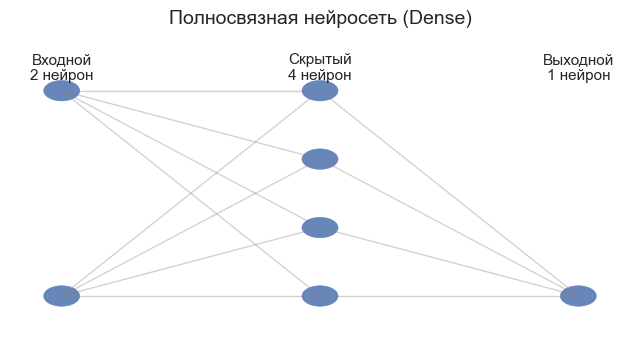

In [5]:
# Простая схема полносвязной сети

def draw_dense_network(layer_sizes, title="Полносвязная нейросеть (Dense)"):
    fig, ax = plt.subplots(figsize=(8, 4))
    max_neurons = max(layer_sizes)
    x_positions = np.linspace(0, 1, len(layer_sizes))
    layer_names = ["Входной", "Скрытый", "Выходной"]

    neuron_positions = []
    for x_pos, size, layer_name in zip(x_positions, layer_sizes, layer_names):
        y_positions = np.linspace(0.15, 0.85, size)
        coords = []
        for y_pos in y_positions:
            circle = plt.Circle((x_pos, y_pos), 0.035, color="#4C72B0", alpha=0.85)
            ax.add_patch(circle)
            coords.append((x_pos, y_pos))
        neuron_positions.append(coords)
        ax.text(x_pos, 0.98, f"{layer_name}\n{size} нейрон", ha="center", va="top", fontsize=11)

    for left_layer, right_layer in zip(neuron_positions[:-1], neuron_positions[1:]):
        for x1, y1 in left_layer:
            for x2, y2 in right_layer:
                ax.plot([x1, x2], [y1, y2], color="gray", alpha=0.35, linewidth=1)

    ax.set_title(title, fontsize=14)
    ax.set_xlim(-0.1, 1.1)
    ax.set_ylim(0, 1.05)
    ax.axis("off")
    plt.show()


draw_dense_network([2, 4, 1])

## 2. Функции активации

После суммы `z` нейрон пропускает результат через функцию активации. Без нее сеть была бы просто одной большой линейной формулой — даже 100 слоев подряд не помогли бы.

| Функция | Что делает | Когда используют |
|---|---|---|
| `ReLU` | Если число > 0, оставляет; иначе 0 | Скрытые слои (по умолчанию) |
| `sigmoid` | Сжимает число в диапазон 0..1 | Выход при бинарной классификации |
| `softmax` | Превращает набор чисел в вероятности (сумма = 1) | Выход при многоклассовой классификации |
| `tanh` | Сжимает число в диапазон -1..1 | Реже, в рекуррентных сетях |

### Простой пример `softmax`
Модель выдала числа: `cat = 2.4`, `dog = 1.1`. Это еще не вероятности. После `softmax` получается: `cat ≈ 0.79`, `dog ≈ 0.21`. Сумма = 1.

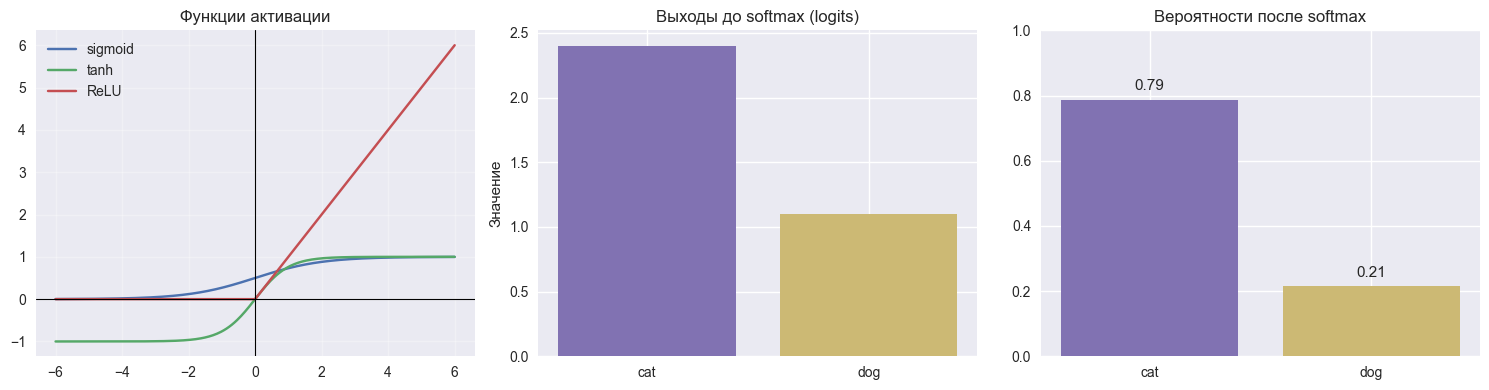

Softmax(cat, dog):
cat: 0.7858
dog: 0.2142
Сумма вероятностей: 1.0000


In [6]:
# Графики функций активации + пример softmax

def sigmoid(x):
    return 1 / (1 + np.exp(-x))


def tanh(x):
    return np.tanh(x)


def relu(x):
    return np.maximum(0, x)


def softmax(x):
    shifted = x - np.max(x)
    exp_values = np.exp(shifted)
    return exp_values / exp_values.sum()


x_values = np.linspace(-6, 6, 300)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(x_values, sigmoid(x_values), label="sigmoid", color="#4C72B0")
axes[0].plot(x_values, tanh(x_values), label="tanh", color="#55A868")
axes[0].plot(x_values, relu(x_values), label="ReLU", color="#C44E52")
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].axvline(0, color="black", linewidth=0.8)
axes[0].set_title("Функции активации")
axes[0].legend()
axes[0].grid(alpha=0.3)

logits = np.array([2.4, 1.1])
probs = softmax(logits)
classes = ["cat", "dog"]

axes[1].bar(classes, logits, color=["#8172B2", "#CCB974"])
axes[1].set_title("Выходы до softmax (logits)")
axes[1].set_ylabel("Значение")

axes[2].bar(classes, probs, color=["#8172B2", "#CCB974"])
axes[2].set_title("Вероятности после softmax")
axes[2].set_ylim(0, 1)
for i, value in enumerate(probs):
    axes[2].text(i, value + 0.03, f"{value:.2f}", ha="center", fontsize=11)

plt.tight_layout()
plt.show()

print("Softmax(cat, dog):")
for cls, prob in zip(classes, probs):
    print(f"{cls}: {prob:.4f}")
print(f"Сумма вероятностей: {probs.sum():.4f}")

## 3. Loss, оптимизаторы, Dropout, `fit()` и `predict()`

### Loss — оценка ошибки
**Loss** — это одно число, которое показывает, **насколько сильно модель ошиблась**.
- Модель уверенно ошиблась → loss большой.
- Модель угадала и была уверена → loss маленький.

Для бинарной классификации обычно берут `binary_crossentropy`, для многоклассовой — `categorical_crossentropy`.

### Оптимизаторы — кто двигает веса

Оптимизатор — это алгоритм, который **смотрит на loss и решает, как подправить веса**, чтобы ошибка стала меньше.

| Оптимизатор | Простыми словами | Когда используют |
|---|---|---|
| `SGD` | Простой градиентный спуск: делает шаг в сторону уменьшения loss | Базовый вариант, иногда нужно вручную подбирать learning rate |
| `Adam` | «Умный» SGD: сам подстраивает размер шага для каждого веса | Используется чаще всего, хороший выбор по умолчанию |
| `RMSprop` | Похож на Adam, но чуть проще | Иногда лучше для рекуррентных сетей |

**Аналогия**: представьте, что вы спускаетесь с горы в тумане. SGD — вы просто идете вниз. Adam — вы идете вниз, но еще запоминаете рельеф и ускоряетесь на пологих участках.

В коде оптимизатор задается при компиляции модели:
```python
model.compile(optimizer="adam", loss="binary_crossentropy")
```

### Dropout — защита от переобучения
Во время обучения случайная часть нейронов **временно выключается**. Это заставляет сеть не полагаться на один единственный путь.

`Dropout(0.2)` означает: каждый раз случайно выключается ~20% нейронов.

### `fit()` — обучение
Метод `fit()` запускает цикл обучения:
1. Прогоняет данные через сеть (forward pass)
2. Считает loss
3. Оптимизатор корректирует веса
4. Повторяет это много раз (эпохи)

### `predict()` — прогноз
Метод `predict()` использует **уже обученные веса** и выдает ответ. Веса не меняются.

In [7]:
# Небольшой пример binary crossentropy вручную

true_labels = np.array([1, 0, 1, 0])
predicted_probs = np.array([0.92, 0.15, 0.60, 0.35])

loss_per_object = -(
    true_labels * np.log(predicted_probs + 1e-8)
    + (1 - true_labels) * np.log(1 - predicted_probs + 1e-8)
)
mean_loss = loss_per_object.mean()

loss_df = pd.DataFrame({
    "y_true": true_labels,
    "p_positive": predicted_probs,
    "loss": np.round(loss_per_object, 4)
})

display(loss_df)
print(f"Средний binary crossentropy: {mean_loss:.4f}")

,y_true,p_positive,loss
0,1,0.92,0.0834
1,0,0.15,0.1625
2,1,0.60,0.5108
3,0,0.35,0.4308


Средний binary crossentropy: 0.2969


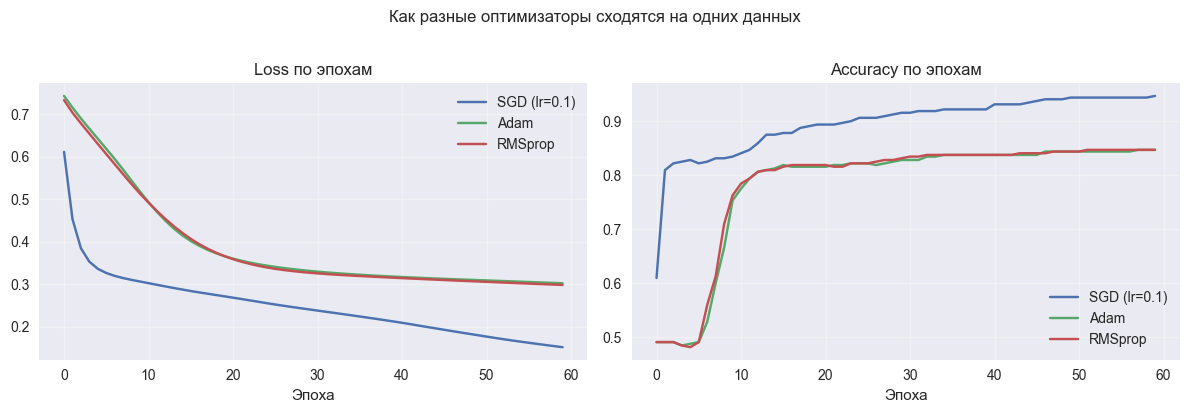

Adam и RMSprop обычно сходятся быстрее, чем простой SGD.
Но SGD может быть полезен, когда нужен аккуратный контроль обучения.


In [8]:
# Сравниваем оптимизаторы на одних и тех же данных

from sklearn.datasets import make_moons as _mm

X_opt, y_opt = _mm(n_samples=400, noise=0.2, random_state=42)
scaler_opt = StandardScaler()
X_opt_sc = scaler_opt.fit_transform(X_opt)

optimizers = {"SGD (lr=0.1)": keras.optimizers.SGD(learning_rate=0.1),
              "Adam":         keras.optimizers.Adam(),
              "RMSprop":      keras.optimizers.RMSprop()}

histories = {}
for name, opt in optimizers.items():
    keras.utils.set_random_seed(42)
    m = keras.Sequential([
        layers.Input(shape=(2,)),
        layers.Dense(8, activation="relu"),
        layers.Dense(1, activation="sigmoid")
    ])
    m.compile(optimizer=opt, loss="binary_crossentropy", metrics=["accuracy"])
    h = m.fit(X_opt_sc, y_opt, epochs=60, batch_size=16, verbose=0, validation_split=0.2)
    histories[name] = h

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for name, h in histories.items():
    axes[0].plot(h.history["loss"], label=name)
    axes[1].plot(h.history["accuracy"], label=name)

axes[0].set_title("Loss по эпохам")
axes[0].set_xlabel("Эпоха")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].set_title("Accuracy по эпохам")
axes[1].set_xlabel("Эпоха")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle("Как разные оптимизаторы сходятся на одних данных", y=1.02)
plt.tight_layout()
plt.show()

print("Adam и RMSprop обычно сходятся быстрее, чем простой SGD.")
print("Но SGD может быть полезен, когда нужен аккуратный контроль обучения.")


## 4. Пример 1: бинарная классификация (две луны)

Генерируем точки двух классов (в форме двух лун) и учим сеть их разделять.

Архитектура модели:
- **Вход**: 2 числа (координаты точки)
- **Скрытый слой**: `Dense(8)` с `ReLU` — 8 нейронов выделяют признаки
- **Dropout(0.2)** — случайно выключает 20% нейронов при обучении
- **Выход**: `Dense(1)` с `sigmoid` — вероятность принадлежности к классу 1

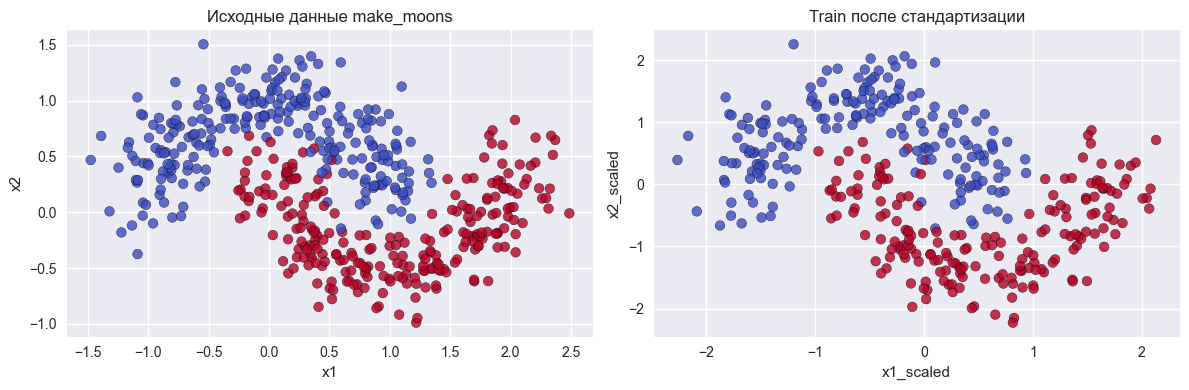

Размер train: (375, 2)
Размер test: (125, 2)


In [9]:
# Генерируем данные и смотрим на них

X, y = make_moons(n_samples=500, noise=0.20, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.25, 
    random_state=42, 
    stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", edgecolor="k", alpha=0.8)
axes[0].set_title("Исходные данные make_moons")
axes[0].set_xlabel("x1")
axes[0].set_ylabel("x2")

axes[1].scatter(X_train_scaled[:, 0], X_train_scaled[:, 1], c=y_train, cmap="coolwarm", edgecolor="k", alpha=0.8)
axes[1].set_title("Train после стандартизации")
axes[1].set_xlabel("x1_scaled")
axes[1].set_ylabel("x2_scaled")

plt.tight_layout()
plt.show()

print(f"Размер train: {X_train.shape}")
print(f"Размер test: {X_test.shape}")

In [10]:
# Первые 10 элементов X
X[:10]

array([[ 0.83085779, -0.33434228],
       [ 0.99170955,  0.87899966],
       [ 1.1072453 , -0.47034376],
       [-0.14089918,  1.03314844],
       [ 0.40559217,  1.32852876],
       [ 1.28895069, -0.52407983],
       [ 1.12079473, -0.27225413],
       [ 0.10659373,  1.21210782],
       [ 0.5201985 ,  0.58288335],
       [ 1.70590095, -0.33306612]])

In [11]:
# Первые 10 элементов y
y[:10]

array([1, 0, 1, 0, 0, 1, 1, 0, 0, 1])

In [12]:
# Создаем и обучаем модель

model = keras.Sequential([
    layers.Input(shape=(2,)),
    layers.Dense(8, activation="relu", name="hidden_dense"),
    layers.Dropout(0.2, name="dropout"),
    layers.Dense(1, activation="sigmoid", name="output")
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

initial_weights = model.get_layer("hidden_dense").get_weights()[0].copy()

history = model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=120,
    batch_size=16,
    verbose=0
)

trained_weights = model.get_layer("hidden_dense").get_weights()[0].copy()
test_loss, test_accuracy = model.evaluate(X_test_scaled, y_test, verbose=0)

print("Структура модели:")
model.summary()
print(f"\nTest loss: {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.4f}")

Структура модели:


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_dense (Dense)            │ (None, 8)              │            24 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101 (408.00 B)

 Trainable params: 33 (132.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 68 (276.00 B)


Test loss: 0.2669
Test accuracy: 0.8480


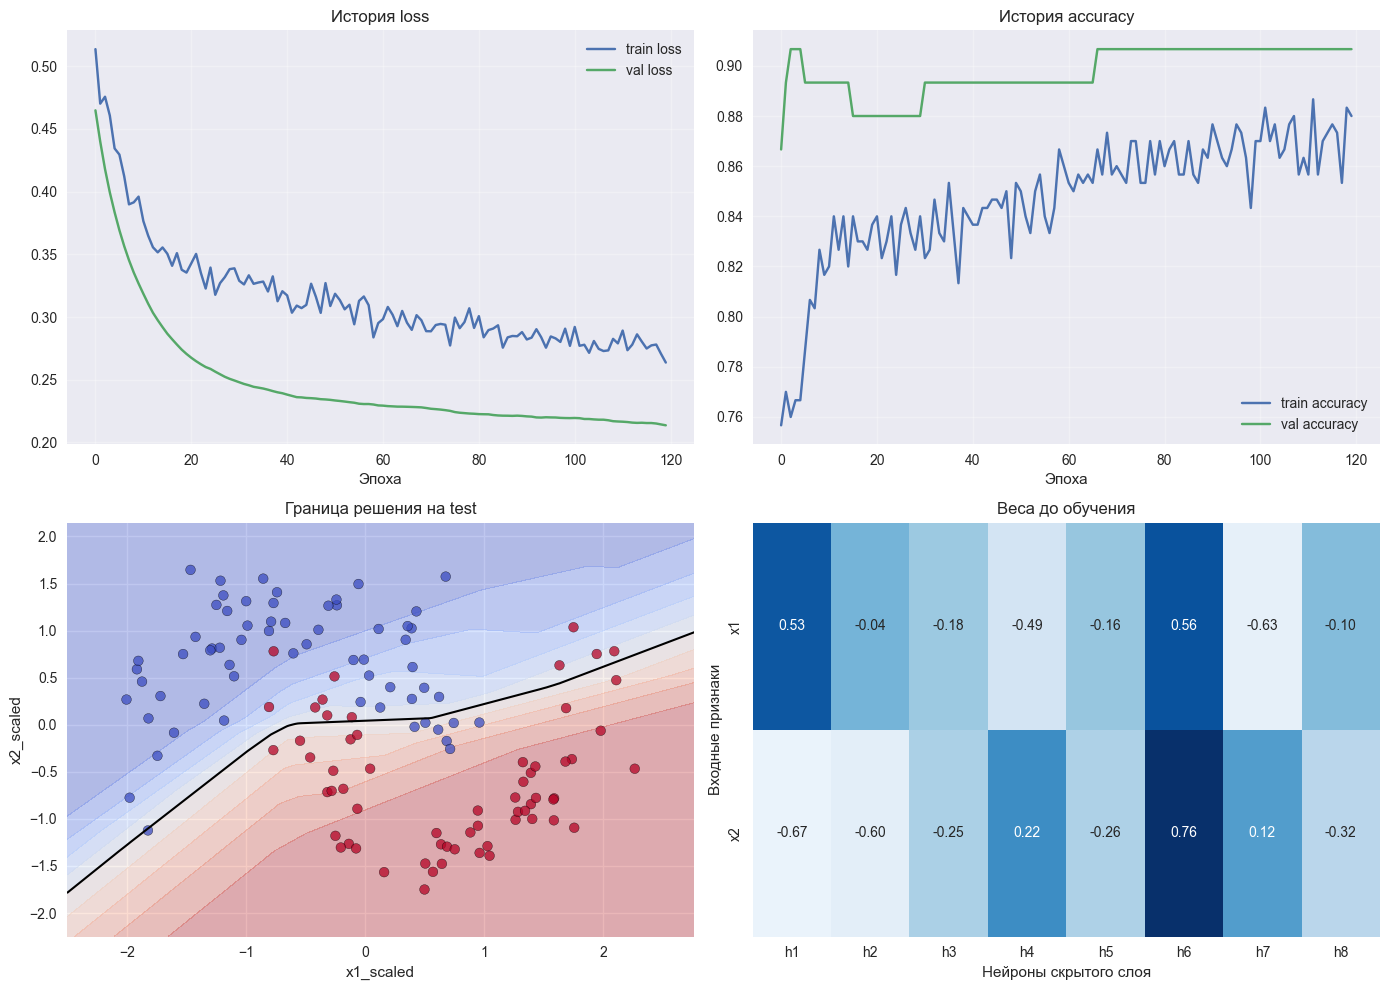

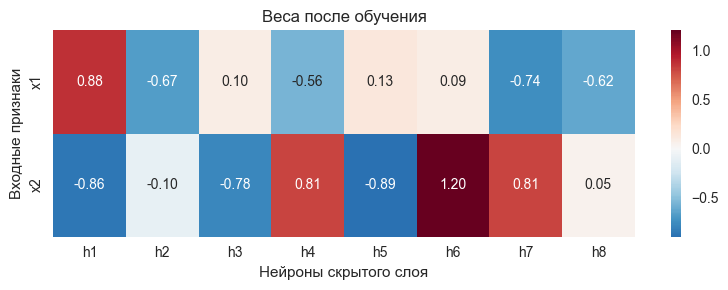

In [13]:
# Визуализируем обучение, границу решения и веса

def plot_decision_boundary(model, X_data, y_data, ax, title):
    x_min, x_max = X_data[:, 0].min() - 0.5, X_data[:, 0].max() + 0.5
    y_min, y_max = X_data[:, 1].min() - 0.5, X_data[:, 1].max() + 0.5
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )
    grid = np.c_[xx.ravel(), yy.ravel()]
    probs = model.predict(grid, verbose=0).reshape(xx.shape)

    ax.contourf(xx, yy, probs, levels=np.linspace(0, 1, 11), cmap="coolwarm", alpha=0.35)
    ax.contour(xx, yy, probs, levels=[0.5], colors="black", linewidths=1.5)
    ax.scatter(X_data[:, 0], X_data[:, 1], c=y_data, cmap="coolwarm", edgecolor="k", alpha=0.75)
    ax.set_title(title)
    ax.set_xlabel("x1_scaled")
    ax.set_ylabel("x2_scaled")


hidden_names = [f"h{i+1}" for i in range(initial_weights.shape[1])]
weight_index = ["x1", "x2"]
initial_df = pd.DataFrame(initial_weights, index=weight_index, columns=hidden_names)
trained_df = pd.DataFrame(trained_weights, index=weight_index, columns=hidden_names)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].plot(history.history["loss"], label="train loss")
axes[0, 0].plot(history.history["val_loss"], label="val loss")
axes[0, 0].set_title("История loss")
axes[0, 0].set_xlabel("Эпоха")
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

axes[0, 1].plot(history.history["accuracy"], label="train accuracy")
axes[0, 1].plot(history.history["val_accuracy"], label="val accuracy")
axes[0, 1].set_title("История accuracy")
axes[0, 1].set_xlabel("Эпоха")
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

plot_decision_boundary(model, X_test_scaled, y_test, axes[1, 0], "Граница решения на test")

sns.heatmap(initial_df, annot=True, cmap="Blues", center=0, fmt=".2f", ax=axes[1, 1], cbar=False)
axes[1, 1].set_title("Веса до обучения")
axes[1, 1].set_xlabel("Нейроны скрытого слоя")
axes[1, 1].set_ylabel("Входные признаки")

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 3))
sns.heatmap(trained_df, annot=True, cmap="RdBu_r", center=0, fmt=".2f", ax=ax)
ax.set_title("Веса после обучения")
ax.set_xlabel("Нейроны скрытого слоя")
ax.set_ylabel("Входные признаки")
plt.tight_layout()
plt.show()

In [14]:
# Что возвращает predict()

sample_count = 8
sample_probs = model.predict(X_test_scaled[:sample_count], verbose=0).flatten()
sample_preds = (sample_probs >= 0.5).astype(int)

predictions_df = pd.DataFrame({
    "x1": np.round(X_test[:sample_count, 0], 3),
    "x2": np.round(X_test[:sample_count, 1], 3),
    "true_class": y_test[:sample_count],
    "predicted_probability": np.round(sample_probs, 3),
    "predicted_class": sample_preds
})

display(predictions_df)

print("`predict()` вернул вероятности принадлежности к положительному классу.")
print("Дальше мы сами превратили вероятности в классы правилом: probability >= 0.5")

,x1,x2,true_class,predicted_probability,predicted_class
0,0.272,-0.022,1,0.734,1
1,-0.021,0.672,0,0.091,0
2,0.193,0.399,1,0.352,0
3,1.722,-0.034,1,0.953,1
4,0.804,0.752,0,0.181,0
5,2.334,0.685,1,0.434,0
6,0.869,0.238,0,0.557,1
7,1.097,1.126,0,0.049,0


`predict()` вернул вероятности принадлежности к положительному классу.
Дальше мы сами превратили вероятности в классы правилом: probability >= 0.5


## 5. Пример 2: распознавание рукописных цифр

Теперь то же самое, но посложнее: картинка `8x8` пикселей → 10 классов (цифры 0–9).

Что изменилось по сравнению с первым примером:
- **Вход**: 64 числа вместо 2
- **Выход**: `softmax` на 10 классов вместо `sigmoid` на 1
- **Loss**: `sparse_categorical_crossentropy` вместо `binary_crossentropy`
- **Ответ**: берем `argmax` из 10 вероятностей

Всё остальное — слои, `ReLU`, `Dropout`, `fit()`, `predict()` — работает точно так же.


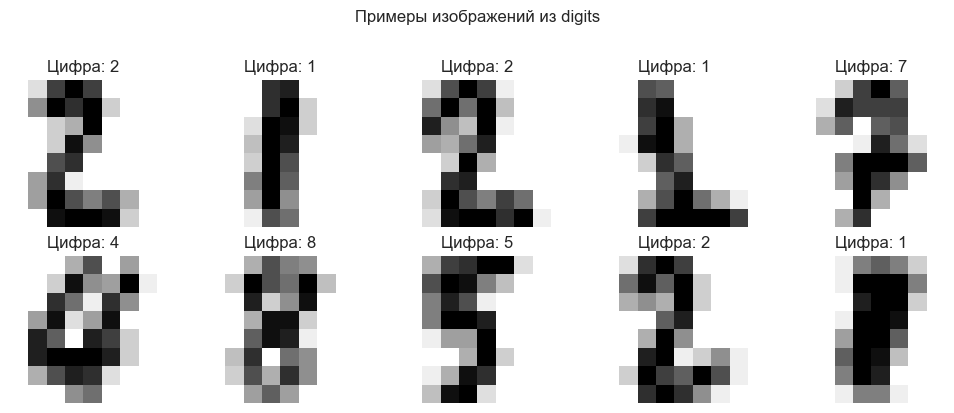

Исходная форма одного изображения: (8, 8) пикселей
После разворачивания каждый объект содержит 64 числовых признаков
Количество классов: 10
Размер train: (1347, 64)
Размер test: (450, 64)


In [15]:
# Загружаем рукописные цифры и смотрим на данные

digits = load_digits()
X_digits = digits.data.astype("float32") / 16.0
y_digits = digits.target
images = digits.images

X_digits_train, X_digits_test, y_digits_train, y_digits_test, images_train, images_test = train_test_split(
    X_digits,
    y_digits,
    images,
    test_size=0.25,
    random_state=42,
    stratify=y_digits
)

fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for ax, image, label in zip(axes.ravel(), images_train[:10], y_digits_train[:10]):
    ax.imshow(image, cmap="gray_r")
    ax.set_title(f"Цифра: {label}")
    ax.axis("off")

plt.suptitle("Примеры изображений из digits", y=1.02)
plt.tight_layout()
plt.show()

print(f"Исходная форма одного изображения: {images.shape[1:]} пикселей")
print(f"После разворачивания каждый объект содержит {X_digits.shape[1]} числовых признаков")
print(f"Количество классов: {len(np.unique(y_digits))}")
print(f"Размер train: {X_digits_train.shape}")
print(f"Размер test: {X_digits_test.shape}")


Структура модели для цифр:


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ digits_hidden_1 (Dense)         │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ digits_dropout (Dropout)        │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ digits_hidden_2 (Dense)         │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ digits_output (Dense)           │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,712 (77.00 KB)

 Trainable params: 6,570 (25.66 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 13,142 (51.34 KB)


Test loss: 0.0923
Test accuracy: 0.9800


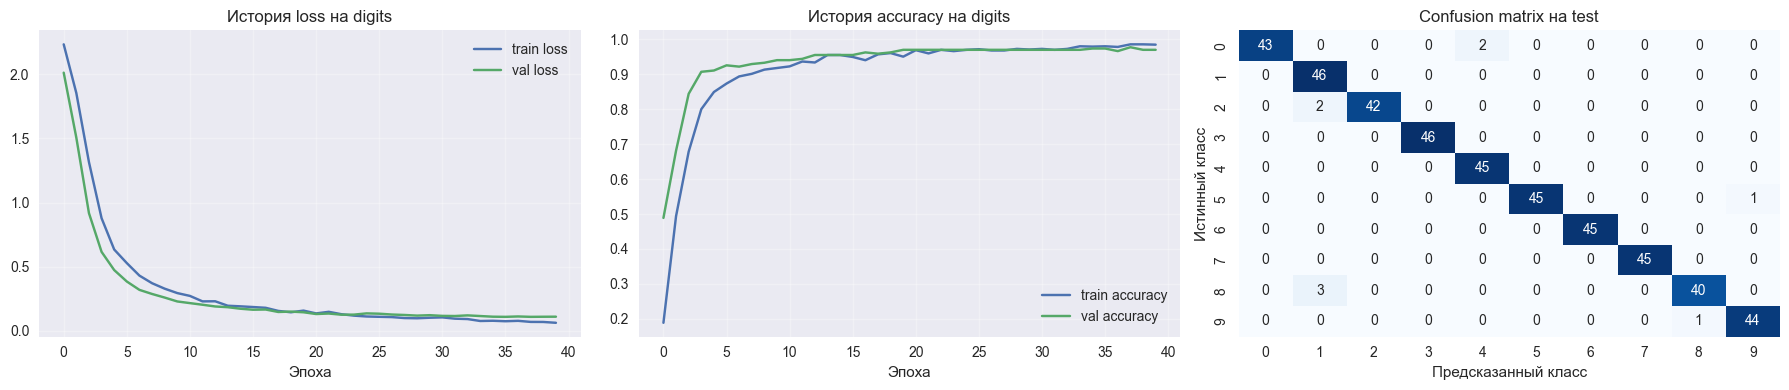

In [16]:
# Обучаем сеть распознавать цифры 0-9

digits_model = keras.Sequential([
    layers.Input(shape=(64,)),
    layers.Dense(64, activation="relu", name="digits_hidden_1"),
    layers.Dropout(0.2, name="digits_dropout"),
    layers.Dense(32, activation="relu", name="digits_hidden_2"),
    layers.Dense(10, activation="softmax", name="digits_output")
])

digits_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

digits_history = digits_model.fit(
    X_digits_train,
    y_digits_train,
    validation_split=0.2,
    epochs=40,
    batch_size=32,
    verbose=0
)

digits_test_loss, digits_test_accuracy = digits_model.evaluate(X_digits_test, y_digits_test, verbose=0)
digit_probs = digits_model.predict(X_digits_test, verbose=0)
digit_preds = digit_probs.argmax(axis=1)
cm = confusion_matrix(y_digits_test, digit_preds)

print("Структура модели для цифр:")
digits_model.summary()
print(f"\nTest loss: {digits_test_loss:.4f}")
print(f"Test accuracy: {digits_test_accuracy:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].plot(digits_history.history["loss"], label="train loss")
axes[0].plot(digits_history.history["val_loss"], label="val loss")
axes[0].set_title("История loss на digits")
axes[0].set_xlabel("Эпоха")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(digits_history.history["accuracy"], label="train accuracy")
axes[1].plot(digits_history.history["val_accuracy"], label="val accuracy")
axes[1].set_title("История accuracy на digits")
axes[1].set_xlabel("Эпоха")
axes[1].legend()
axes[1].grid(alpha=0.3)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[2], cbar=False)
axes[2].set_title("Confusion matrix на test")
axes[2].set_xlabel("Предсказанный класс")
axes[2].set_ylabel("Истинный класс")

plt.tight_layout()
plt.show()


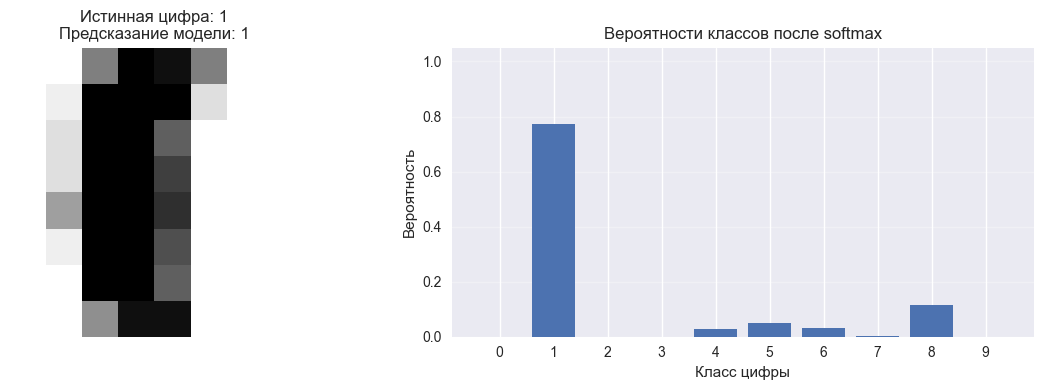

,digit,probability
0,1,0.7730
1,8,0.1145
2,5,0.0510
3,6,0.0316
4,4,0.0275
5,7,0.0012
6,9,0.0006
7,2,0.0005
8,0,0.0001
9,3,0.0000


Последовательность работы модели на одной картинке:
1. На вход приходит изображение 8x8, которое разворачивается в вектор из 64 пикселей.
2. Скрытые слои Dense превращают пиксели в более полезные внутренние признаки.
3. Выходной слой с softmax возвращает 10 вероятностей: по одной для каждой цифры.
4. Самые вероятные варианты для этого примера: 1 (0.773), 8 (0.114), 5 (0.051)
5. Через argmax модель выбирает класс 1.


In [17]:
# Разбираем предсказание одной рукописной цифры по шагам

sample_index = 0
sample_vector = X_digits_test[sample_index:sample_index + 1]
sample_image = images_test[sample_index]
sample_true = int(y_digits_test[sample_index])

sample_prob_vector = digits_model.predict(sample_vector, verbose=0)[0]
sample_pred = int(np.argmax(sample_prob_vector))
top3 = np.argsort(sample_prob_vector)[-3:][::-1]
top3_text = ", ".join(
    f"{digit} ({sample_prob_vector[digit]:.3f})" for digit in top3
)

probabilities_df = pd.DataFrame({
    "digit": np.arange(10),
    "probability": np.round(sample_prob_vector, 4)
}).sort_values("probability", ascending=False).reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(sample_image, cmap="gray_r")
axes[0].set_title(f"Истинная цифра: {sample_true}\nПредсказание модели: {sample_pred}")
axes[0].axis("off")

axes[1].bar(np.arange(10), sample_prob_vector, color="#4C72B0")
axes[1].set_title("Вероятности классов после softmax")
axes[1].set_xlabel("Класс цифры")
axes[1].set_ylabel("Вероятность")
axes[1].set_xticks(np.arange(10))
axes[1].set_ylim(0, 1.05)
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

display(probabilities_df)

print("Последовательность работы модели на одной картинке:")
print("1. На вход приходит изображение 8x8, которое разворачивается в вектор из 64 пикселей.")
print("2. Скрытые слои Dense превращают пиксели в более полезные внутренние признаки.")
print("3. Выходной слой с softmax возвращает 10 вероятностей: по одной для каждой цифры.")
print(f"4. Самые вероятные варианты для этого примера: {top3_text}")
print(f"5. Через argmax модель выбирает класс {sample_pred}.")


## Итог

Нейросеть — не магия, а конструктор из простых деталей:

| Деталь | Зачем |
|---|---|
| `Dense` | Полносвязный слой — основной строительный блок |
| `ReLU` / `sigmoid` / `softmax` | Функции активации — добавляют нелинейность |
| `loss` | Число ошибки — сеть стремится его уменьшить |
| Оптимизатор (`Adam`, `SGD`) | Алгоритм, который двигает веса |
| `Dropout` | Защита от переобучения |
| `fit()` | Запуск обучения |
| `predict()` | Получение прогноза |

Одна и та же цепочка **вход → слои → активации → loss → оптимизатор → predict** работает и на игрушечных данных, и на цифрах, и (как увидим дальше) на текстах. 